|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 0:</h2>|<h1>From a Program to a Model<h1>|
|<h2>Section:</h2>|<h1>How to measure<h1>|
|<h2>Lecture:</h2>|<h1><b>How does the cost grow?<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

# How does the cost grow?

A number is true at one size. Production runs at the next size. So the
question that matters most is often not "how long does this take?", but
"what happens to the time when the input grows?"

This is **move 4** of `docs/METHOD.md`: read the shape. This notebook gives
you three tools for it, from the simplest to the most formal. Use them in
this order.

In [1]:
# find the repo root. The directory you start from does not matter.
import sys
from pathlib import Path
ROOT = next(folder for folder in [Path.cwd(), *Path.cwd().parents]
            if (folder/'cudalib').is_dir())
sys.path.insert(0, str(ROOT))

import time
import numpy as np
import torch
import matplotlib.pyplot as plt
import cudalib

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

Three functions, each of a length `L`:

- `project(L)`: each of `L` tokens goes through one layer of weights. The work
  grows with `L`.
- `scores(L)`: each of `L` tokens is compared with every other token. The work
  grows with `L x L`.
- `model_like(L)`: a fixed read of 192 MB, like the weights of a small model,
  plus both of the above. This one is like one real forward pass.

The code of the first two tells you their shape. The third is the kind of
function that you meet in real work: a mix of terms, and you do not know
which one wins.

In [2]:
WIDTH = 2048
W = torch.randn(WIDTH, WIDTH, device='cuda', dtype=torch.bfloat16)
FIXED = torch.randn(96 * 2**20, device='cuda', dtype=torch.bfloat16)      # 192 MB

def project(L):
    activations = torch.randn(L, WIDTH, device='cuda', dtype=torch.bfloat16)
    return lambda: activations @ W

def scores(L):
    q = torch.randn(L, 128, device='cuda', dtype=torch.bfloat16)
    return lambda: q @ q.T

def model_like(L):
    run_project, run_scores = project(L), scores(L)
    return lambda: (FIXED.sum(), run_project(), run_scores())

# Tool 1: double it, and divide

Time the function at `L`, and at `2L`. Divide the second time by the first:

| `t(2L) / t(L)` | The shape |
|---|---|
| about 1 | flat: the size does not matter |
| about 2 | linear |
| about 4 | quadratic |

You can do this in your head, and it needs no plot. Predict the ratio of
`model_like` for a doubling from 1024 to 2048, and from 8192 to 16384.

In [3]:
PREDICTED_SMALL = None      # model_like: t(2048) / t(1024)
PREDICTED_LARGE = None      # model_like: t(16384) / t(8192)

In [4]:
LENGTHS = np.array([512, 1024, 2048, 4096, 8192, 16384])
TIMES = {name: np.array([cudalib.bench_ms(function(int(L)), iters=20, warmup=5, best_of=3)
                         for L in LENGTHS])
         for name, function in [('project', project), ('scores', scores), ('model_like', model_like)]}

print(f"{'L':>6}" + ''.join(f'{name:>22}' for name in TIMES))
for index, L in enumerate(LENGTHS):
    row = f'{L:>6}'
    for name, times in TIMES.items():
        doubling_label = f'x{times[index]/times[index-1]:.2f}' if index else ''
        row += f'{times[index]:>12.3f} ms {doubling_label:>6}'
    print(row)

     L               project                scores            model_like
   512       0.106 ms              0.006 ms              0.743 ms       
  1024       0.180 ms  x1.70       0.015 ms  x2.67       0.793 ms  x1.07
  2048       0.388 ms  x2.15       0.031 ms  x2.07       0.959 ms  x1.21
  4096       0.663 ms  x1.71       0.101 ms  x3.21       1.277 ms  x1.33
  8192       1.312 ms  x1.98       0.414 ms  x4.10       2.256 ms  x1.77
 16384       2.647 ms  x2.02       1.643 ms  x3.97       5.046 ms  x2.24


Read the `model_like` column from top to bottom. At small `L` the doubling
ratio is near 1: the function looks flat. At large `L` it grows past 2, and
it continues to move toward 4.

Both readings are true. At small `L` the fixed 192 MB read is almost all of
the time, so the other terms hide. At large `L` the `L x L` term wins. **The
shape of a mix changes with the size.** A table of small sizes shows you only
the term that wins at small sizes.

This is exactly how a quadratic cost reaches production. At the sizes that
the tests use, it looks flat.

`scores` also shows something at small `L`: its ratio is not 4 there. At
small sizes a fixed cost, such as the kernel launch, is a large part of a
tiny time. Always read the ratio at the large end.

# Tool 2: a log-log plot

On a plot with both axes in log scale, `t = c x L^k` is a straight line, and
its slope is the exponent `k`. So the slope tells you the shape, at each
size, and you can see where it bends.

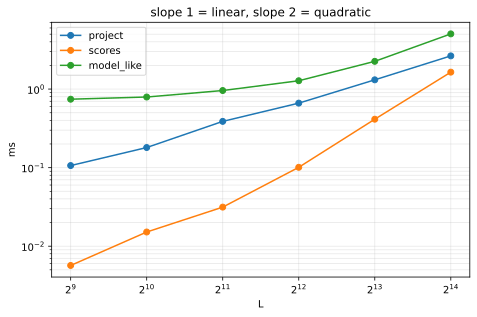

   project: slope between each pair of sizes  0.76  1.11  0.77  0.99  1.01
    scores: slope between each pair of sizes  1.42  1.05  1.68  2.03  1.99
model_like: slope between each pair of sizes  0.09  0.27  0.41  0.82  1.16


In [5]:
plt.figure(figsize=(7.5, 4.6))
for name, times in TIMES.items():
    plt.plot(LENGTHS, times, 'o-', label=name)
plt.xscale('log', base=2)
plt.yscale('log')
plt.xlabel('L')
plt.ylabel('ms')
plt.title('slope 1 = linear, slope 2 = quadratic')
plt.legend()
plt.grid(alpha=.3, which='both')
plt.show()

for name, times in TIMES.items():
    slopes = np.diff(np.log(times)) / np.diff(np.log(LENGTHS))
    print(f'{name:>10}: slope between each pair of sizes  ' + '  '.join(f'{slope:4.2f}' for slope in slopes))

The slope is the doubling test in a different form: a ratio of 2 is a slope
of 1, and a ratio of 4 is a slope of 2. The plot adds one thing: you see the
bend of `model_like`, and where it is.

# Tool 3: a fit

The first two tools tell you the shape. A **fit** tells you the size of each
term, so that you can predict a size that you did not measure.

Suppose that the time is `t(L) = c + b L + a L^2`. `np.polyfit` finds the
`c`, `b` and `a` that are closest to the measurements. The code names them
`constant_ms`, `l_coef` and `l_squared_coef`. The raw value of `l_squared_coef`
means nothing by itself, because it depends on the units. Ask a better
question: **at each length, what share of the time is the `L^2` term?**

In [6]:
l_squared_coef, l_coef, constant_ms = np.polyfit(LENGTHS, TIMES['model_like'], 2)
print(f't(L) = {constant_ms:.3f} + {l_coef:.2e} L + {l_squared_coef:.2e} L^2   (ms)\n')
for L in [1024, 4096, 16384, 65536]:
    quadratic = l_squared_coef * L * L
    predicted_ms = constant_ms + l_coef * L + quadratic
    measured = '' if L > LENGTHS[-1] else '   (measured)'
    print(f'at L = {L:>6}: the L^2 term is {100*quadratic/predicted_ms:5.1f}% of the time{measured}')

t(L) = 0.672 + 1.16e-04 L + 9.22e-09 L^2   (ms)

at L =   1024: the L^2 term is   1.2% of the time   (measured)
at L =   4096: the L^2 term is  11.9% of the time   (measured)
at L =  16384: the L^2 term is  49.0% of the time   (measured)
at L =  65536: the L^2 term is  82.7% of the time


At 65536, which you did not measure, the fit predicts that the `L^2` term is
most of the time. That is the value of the fit: it goes beyond the
data. It is also the risk: a fit is only as good as the sizes that you gave
it. Check a prediction of a fit with one real measurement when you can.

### When to use which tool

| Tool | Use it when | Trap |
|---|---|---|
| Double it, and divide | always first: in your head, or on paper | small sizes, where a fixed cost hides the shape |
| A log-log plot | you want to see where the shape changes | a straight line through three points proves little |
| A fit | you must predict a size that you cannot measure | a fit on small sizes, where the big term is hidden |

### What to remember from this notebook

- Ask "what happens when it doubles?" before any other question about size.
- The shape of a mix changes with the size. Read the ratio at the large end.
- The fit comes last. It separates the terms, and it predicts beyond the data.

Part 1, section 3, uses these three tools on the real model, to find the cost
of a loop that forgets its work.